In [1]:
# Cellule 1 — Imports + chargement CSV

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


df = pd.read_csv("cmp_expertv4_vs_ppo_v7_104weeks.csv")
print(df.shape)
df.head()


(104, 5)


,week_id,seed,reward_expert_v4,reward_ppo_v7,diff_ppo_minus_expert
0,1,50000,12833.80,15761.48,2927.68
1,2,50001,13077.22,15123.32,2046.10
2,3,50002,13094.10,15965.80,2871.70
3,4,50003,13790.94,16358.52,2567.58
4,5,50004,13382.12,15755.02,2372.90


In [2]:
# Cellule 2 — Sanity check

assert len(df) == 104
df.describe()


,week_id,seed,reward_expert_v4,reward_ppo_v7,diff_ppo_minus_expert
count,104.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,50051.500000,13310.849038,15768.534231,2457.685192
std,30.166206,30.166206,553.106242,387.050096,669.432108
min,1.000000,50000.000000,11831.620000,14811.860000,1007.660000
25%,26.750000,50025.750000,12957.830000,15481.710000,2081.470000
50%,52.500000,50051.500000,13282.560000,15767.830000,2440.220000
75%,78.250000,50077.250000,13611.115000,16053.225000,2884.880000
max,104.000000,50103.000000,15058.380000,16872.320000,4053.100000


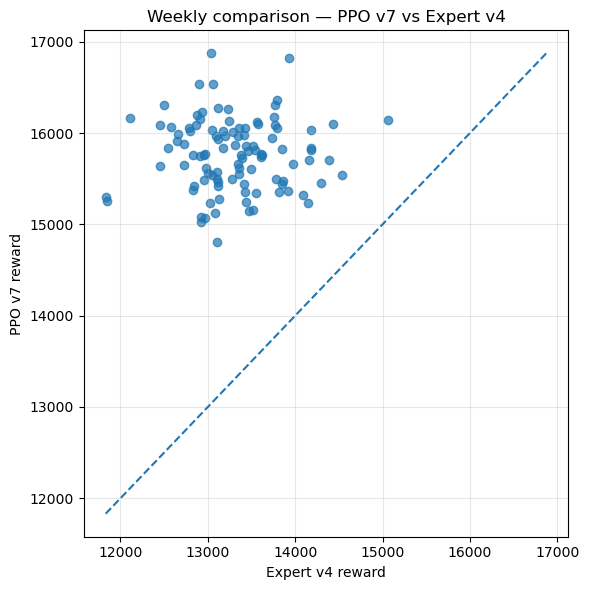

In [3]:
# Cellule 3 : Scatter Expert vs PPO

plt.figure(figsize=(6,6))
plt.scatter(
    df["reward_expert_v4"],
    df["reward_ppo_v7"],
    alpha=0.7
)
m = min(df["reward_expert_v4"].min(), df["reward_ppo_v7"].min())
M = max(df["reward_expert_v4"].max(), df["reward_ppo_v7"].max())
plt.plot([m, M], [m, M], linestyle="--")  # ligne y=x

plt.xlabel("Expert v4 reward")
plt.ylabel("PPO v7 reward")
plt.title("Weekly comparison — PPO v7 vs Expert v4")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


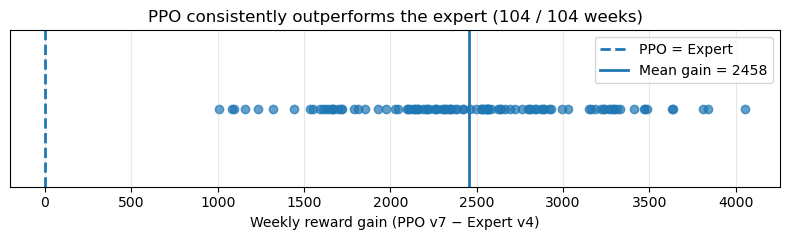

In [11]:
# Cellule 4 — Gain PPO vs Expert : dot plot 

import numpy as np
import matplotlib.pyplot as plt

diff = df["diff_ppo_minus_expert"].values

plt.figure(figsize=(8, 2.5))

# Points (une semaine = un point)
y = np.zeros_like(diff)
plt.scatter(diff, y, alpha=0.7)

# Ligne zéro
plt.axvline(0, linestyle="--", linewidth=2, label="PPO = Expert")

# Ligne moyenne
plt.axvline(
    diff.mean(),
    linestyle="-",
    linewidth=2,
    label=f"Mean gain = {diff.mean():.0f}"
)

plt.yticks([])
plt.xlabel("Weekly reward gain (PPO v7 − Expert v4)")
plt.title("PPO consistently outperforms the expert (104 / 104 weeks)")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
